# --- Notebook : Modèle Radial_Basis_Neural_Network - Cas de Tests de Régression + classifiocation ---

In [8]:
# --- Notebook : Modèle Linéaire - Cas de Tests de Régression ---
import ctypes
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from sklearn.preprocessing import OneHotEncoder

In [3]:
# === Chargement de la bibliothèque Rust compilée ===
lib = ctypes.CDLL("target/release/mymodel.dll")

In [4]:
# === Création du modèle RBFN ===
lib.create_rbfn_regression_model.argtypes = [
    ctypes.c_size_t,  # n_hidden
    ctypes.c_double,  # sigma
    ctypes.c_double,  # learning_rate
    ctypes.c_size_t   # epochs
]
lib.create_rbfn_regression_model.restype = ctypes.c_void_p

lib.create_rbfn_binary_classification_model.argtypes = [
    ctypes.c_size_t,  # n_hidden
    ctypes.c_double,  # sigma
    ctypes.c_double,  # learning_rate
    ctypes.c_size_t   # epochs
]
lib.create_rbfn_binary_classification_model.restype = ctypes.c_void_p

lib.create_rbfn_multiclass_model.argtypes = [
    ctypes.c_size_t,  # n_hidden
    ctypes.c_double,  # sigma
    ctypes.c_double,  # learning_rate
    ctypes.c_size_t,  # epochs
    ctypes.c_size_t   # n_classes
]
lib.create_rbfn_multiclass_model.restype = ctypes.c_void_p

# === Entraînement automatique ===
lib.train_rbfn_model_auto.argtypes = [
    ctypes.c_void_p,                    # model_ptr
    ctypes.POINTER(ctypes.c_double),   # x_ptr
    ctypes.POINTER(ctypes.c_double),   # y_ptr
    ctypes.c_size_t,                   # n_samples
    ctypes.c_size_t,                   # n_features
    ctypes.c_size_t                    # n_outputs (1 pour régression/binaire, >1 pour multiclasses)
]

# === Prédiction ===
lib.predict_rbfn_model.argtypes = [
    ctypes.c_void_p,                    # model_ptr
    ctypes.POINTER(ctypes.c_double),   # x_ptr
    ctypes.c_size_t                    # n_features
]
lib.predict_rbfn_model.restype = ctypes.c_double


# Fonction pour entrainer, tester et visualiser pour la regression / classification binaire et classification multiclasses

In [5]:
def test_rbfn_model(lib, X, Y, name, mode, n_classes=None, n_hidden=10):
    import matplotlib.pyplot as plt
    from mpl_toolkits.mplot3d import Axes3D
    import ctypes
    import numpy as np

    print(f"\n--- {name} ---")

    X = X.astype(np.float64)
    X_flat = X.flatten()

    if mode == "regression":
        print("Mode : Régression (solution analytique)")
        model = lib.create_rbfn_regression_model(n_hidden, 1.0, 0.1, 1000)
        Y_flat = Y.astype(np.float64).flatten()
        n_outputs = 1

    elif mode == "binary":
        print("Mode : Classification binaire (solution analytique)")
        model = lib.create_rbfn_binary_classification_model(n_hidden, 1.0, 0.1, 1000)
        Y_flat = Y.astype(np.float64).flatten()
        n_outputs = 1

    elif mode == "multiclass":
        if n_classes is None:
            raise ValueError("Vous devez fournir le nombre de classes pour la classification multiclasse.")
        print("Mode : Classification multiclasses (descente de gradient)")
        model = lib.create_rbfn_multiclass_model(n_hidden, 1.0, 0.1, 1000, n_classes)
        Y_flat = Y.astype(np.float64).flatten()
        n_outputs = n_classes

    else:
        raise ValueError(f"Mode inconnu : {mode}")

    # Entraînement
    lib.train_rbfn_model_auto(
        model,
        X_flat.ctypes.data_as(ctypes.POINTER(ctypes.c_double)),
        Y_flat.ctypes.data_as(ctypes.POINTER(ctypes.c_double)),
        X.shape[0], X.shape[1], n_outputs
    )

    # Prédiction + affichage
    predictions = []
    for i in range(len(X)):
        x = X[i].astype(np.float64)
        pred = lib.predict_rbfn_model(
            model,
            x.ctypes.data_as(ctypes.POINTER(ctypes.c_double)),
            len(x)
        )
        predictions.append(pred)
        print(f"Exemple {i} : Prédit = {pred:.3f}, Vrai = {Y[i]}")

    # Visualisation
    predictions = np.array(predictions)

    if X.shape[1] == 1:
        plt.figure()
        plt.title(name)
        plt.scatter(X[:, 0], Y, label="Vrai", color="blue")
        plt.plot(X[:, 0], predictions, label="Prédit", color="red")
        plt.xlabel("X")
        plt.ylabel("Y")
        plt.legend()
        plt.grid(True)
        plt.show()

    elif X.shape[1] == 2:
        plt.figure()
        plt.title(name)
        plt.scatter(range(len(Y)), Y, label="Vrai", color="blue")
        plt.plot(range(len(Y)), predictions, label="Prédit", color="red")
        plt.xlabel("Index")
        plt.ylabel("Y")
        plt.legend()
        plt.grid(True)
        plt.show()

    elif X.shape[1] == 3:
        fig = plt.figure()
        ax = fig.add_subplot(111, projection='3d')
        ax.set_title(name)
        ax.scatter(X[:, 0], X[:, 1], Y, color='blue', label='Vrai')
        ax.scatter(X[:, 0], X[:, 1], predictions, color='red', label='Prédit')
        ax.set_xlabel("X1")
        ax.set_ylabel("X2")
        ax.set_zlabel("Y")
        ax.legend()
        plt.show()


# Cas de test simple _regression_


--- RBFN - Régression simple ---
Mode : Régression (solution analytique)
Exemple 0 : Prédit = -1.782, Vrai = -0.649532362689631
Exemple 1 : Prédit = 1.849, Vrai = 2.5042991565215775
Exemple 2 : Prédit = 1.969, Vrai = 2.594815782077937
Exemple 3 : Prédit = -1.582, Vrai = -0.4152992661857877
Exemple 4 : Prédit = -1.085, Vrai = 0.11120132225042312
Exemple 5 : Prédit = 1.621, Vrai = 2.3326907913560757
Exemple 6 : Prédit = 1.499, Vrai = 2.2409938107583685
Exemple 7 : Prédit = 2.354, Vrai = 2.8869402581253416
Exemple 8 : Prédit = -1.785, Vrai = -0.6528278082903376
Exemple 9 : Prédit = -1.896, Vrai = -0.7898227741370185
Exemple 10 : Prédit = 2.000, Vrai = 2.6181629054082185
Exemple 11 : Prédit = 0.592, Vrai = 1.55052207849762
Exemple 12 : Prédit = -1.689, Vrai = -0.5393238621677896
Exemple 13 : Prédit = 2.354, Vrai = 2.88689508568184
Exemple 14 : Prédit = -1.993, Vrai = -0.9148083700278091
Exemple 15 : Prédit = -0.093, Vrai = 1.0040077512269088
Exemple 16 : Prédit = 0.188, Vrai = 1.232744707

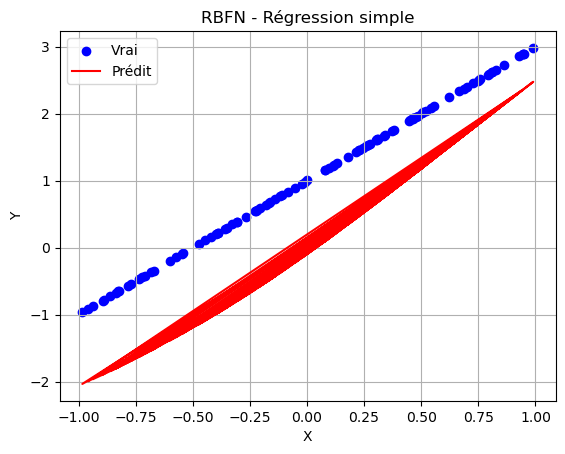

In [6]:
# === Régression simple ===
X = np.random.uniform(-1, 1, (100, 1))
Y = 2 * X[:, 0] + 1
test_rbfn_model(lib, X, Y, "RBFN - Régression simple", mode="regression")

#  Cas 1 : Linear Simple 2D 


--- RBFN - Régression Linear Simple 2D ---
Mode : Régression (solution analytique)
Exemple 0 : Prédit = 2.000, Vrai = 2
Exemple 1 : Prédit = 4.000, Vrai = 4
Exemple 2 : Prédit = 6.000, Vrai = 6


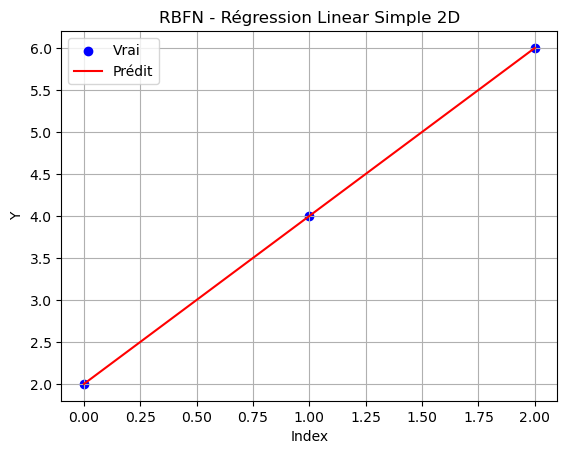

In [7]:
# === Cas 1 : Linear Simple 2D ===
X1 = np.array([
    [1, 1],
    [2, 2],
    [3, 3]
])
Y1 = np.array([2, 4, 6])
test_rbfn_model(lib, X1, Y1, "RBFN - Régression Linear Simple 2D", mode="regression")



# Cas 2 : Non Linear Simple 2D


--- RBFN - Non Linear Simple 2D ---
Mode : Régression (solution analytique)
Exemple 0 : Prédit = 1.000, Vrai = 1
Exemple 1 : Prédit = 8.000, Vrai = 8
Exemple 2 : Prédit = 27.000, Vrai = 27


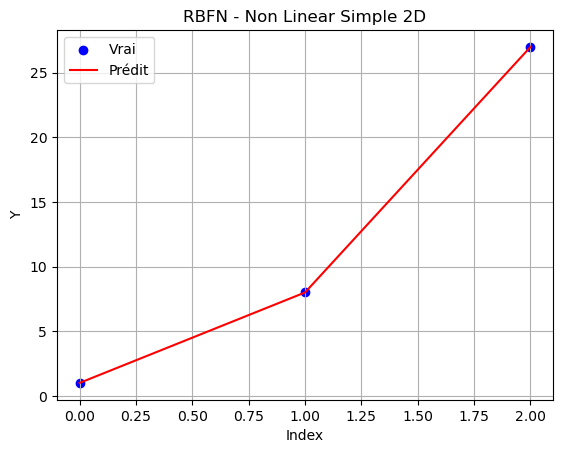

In [8]:
# === Cas 2 : Non Linear Simple 2D ===
X2 = np.array([
    [1, 1],
    [2, 2],
    [3, 3]
])
Y2 = np.array([1, 8, 27])  # y = x^3

test_rbfn_model(lib, X2, Y2, "RBFN - Non Linear Simple 2D", mode="regression")

# Cas 3 : Linear Simple 3D


--- RBFN - Régression simple (3D) ---
Mode : Régression (solution analytique)
Exemple 0 : Prédit = 3.000, Vrai = 3
Exemple 1 : Prédit = 6.000, Vrai = 6
Exemple 2 : Prédit = 9.000, Vrai = 9


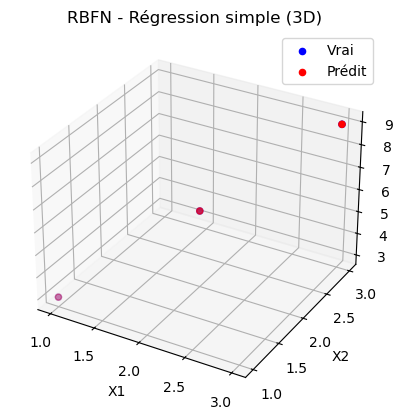

In [9]:
# === Cas 3 : Linear Simple 3D ===
X3 = np.array([
    [1, 1, 1],
    [2, 2, 2],
    [3, 3, 3]
])
Y3 = np.array([3, 6, 9])
test_rbfn_model(lib, X3, Y3, "RBFN - Régression simple (3D)", mode="regression")

# cas 4 : Non Linear Simple 3D


--- RBFN - Non Linear Simple 3D ---
Mode : Régression (solution analytique)
Exemple 0 : Prédit = 3.000, Vrai = 3
Exemple 1 : Prédit = 6.000, Vrai = 6
Exemple 2 : Prédit = 9.000, Vrai = 9


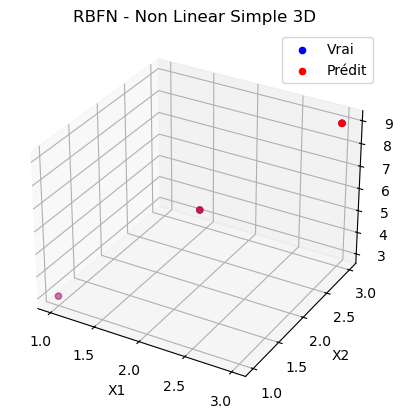

In [10]:
# === Cas 5 : Non Linear Simple 3D ===
X5 = np.array([
    [1, 2, 1],
    [2, 3, 2],
    [3, 4, 3]
])
Y5 = np.array([4, 27, 64])  # y = (x1 + x2)^2 * x3
test_rbfn_model(lib, X3, Y3, "RBFN - Non Linear Simple 3D", mode="regression")

# Tets pour la classification

# Cas 1 : Linear Simple


--- Classification binaire - Linear Simple ---
Mode : Classification binaire (solution analytique)
Exemple 0 : Prédit = 1.000, Vrai = 1
Exemple 1 : Prédit = 1.000, Vrai = 1
Exemple 2 : Prédit = 1.000, Vrai = 1
Exemple 3 : Prédit = -1.000, Vrai = -1
Exemple 4 : Prédit = -1.000, Vrai = -1
Exemple 5 : Prédit = -1.000, Vrai = -1


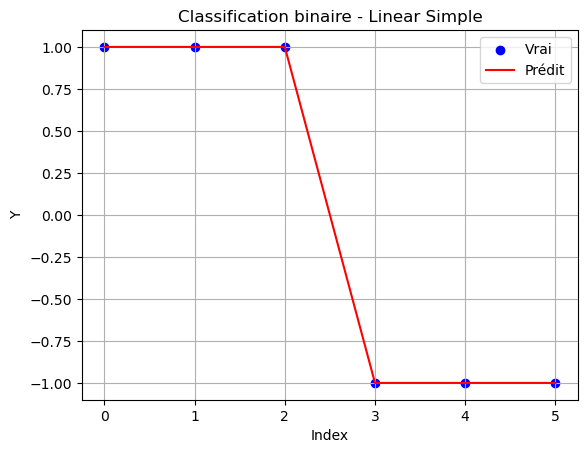

In [11]:
# === Cas 1 : Linear Simple ===
X_cls1 = np.array([
    [1, 1], [2, 2], [3, 3],
    [1, 4], [2, 5], [3, 6]
])
Y_cls1 = np.array([1, 1, 1, -1, -1, -1])
test_rbfn_model(lib, X_cls1, Y_cls1, "Classification binaire - Linear Simple", mode="binary")

# cas 2 : Linear Multiple


--- Classification bianire - Linear Multiple ---
Mode : Classification binaire (solution analytique)
Exemple 0 : Prédit = 1.000, Vrai = 1
Exemple 1 : Prédit = 1.000, Vrai = 1
Exemple 2 : Prédit = 1.000, Vrai = 1
Exemple 3 : Prédit = 1.000, Vrai = 1
Exemple 4 : Prédit = 1.000, Vrai = 1
Exemple 5 : Prédit = 1.000, Vrai = 1
Exemple 6 : Prédit = -1.000, Vrai = -1
Exemple 7 : Prédit = -1.000, Vrai = -1
Exemple 8 : Prédit = -1.000, Vrai = -1
Exemple 9 : Prédit = -1.000, Vrai = -1
Exemple 10 : Prédit = -1.000, Vrai = -1
Exemple 11 : Prédit = -1.000, Vrai = -1


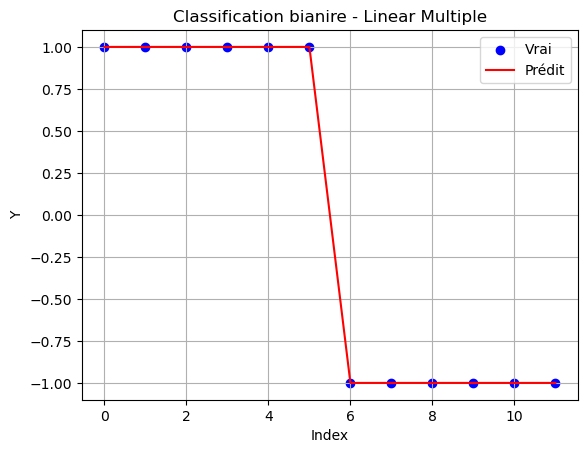

In [12]:
# === Cas 2 : Linear Multiple ===
X_cls2 = np.array([
    [1, 1], [2, 2], [3, 3],
    [4, 4], [5, 5], [6, 6],
    [1, 6], [2, 7], [3, 8],
    [4, 9], [5, 10], [6, 11]
])
Y_cls2 = np.array([1, 1, 1, 1, 1, 1, -1, -1, -1, -1, -1, -1])
test_rbfn_model(lib, X_cls2, Y_cls2, "Classification bianire - Linear Multiple", mode="binary")

# cas 3 : XOR


--- RBFN - Classification binaire XOR ---
Mode : Classification binaire (solution analytique)
Exemple 0 : Prédit = -1.000, Vrai = -1
Exemple 1 : Prédit = 1.000, Vrai = 1
Exemple 2 : Prédit = 1.000, Vrai = 1
Exemple 3 : Prédit = -1.000, Vrai = -1


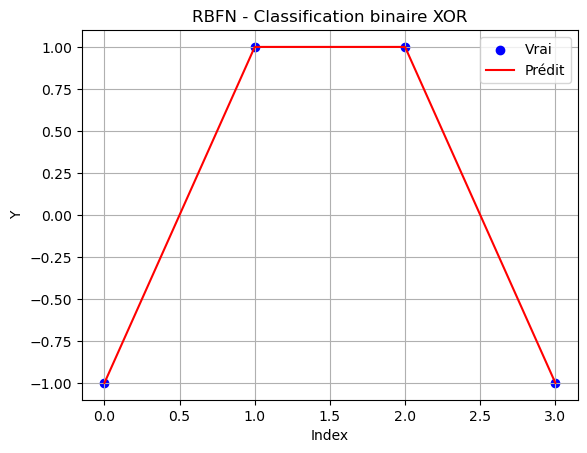

In [13]:
# Exemple : XOR (2D, binaire non-linéaire)
X = np.array([
    [0, 0],
    [0, 1],
    [1, 0],
    [1, 1]
])
Y = np.array([-1, 1, 1, -1])  # binaire en {-1, 1} comme ton modèle RBFN attend
test_rbfn_model(lib, X, Y, "RBFN - Classification binaire XOR", mode="binary")


# Cas 4 : Cross


--- Classification - Cross ---
Mode : Classification binaire (solution analytique)
Exemple 0 : Prédit = 1.000, Vrai = 1
Exemple 1 : Prédit = 1.000, Vrai = 1
Exemple 2 : Prédit = 1.000, Vrai = 1
Exemple 3 : Prédit = 1.000, Vrai = 1
Exemple 4 : Prédit = 1.000, Vrai = 1
Exemple 5 : Prédit = 1.000, Vrai = 1
Exemple 6 : Prédit = -1.000, Vrai = -1
Exemple 7 : Prédit = -1.000, Vrai = -1
Exemple 8 : Prédit = -1.000, Vrai = -1


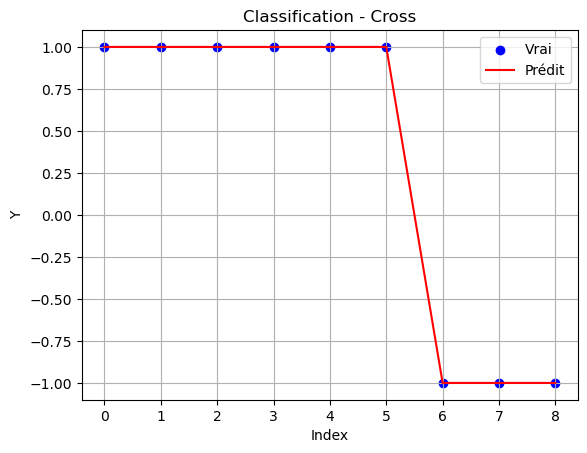

In [9]:
# === Cas 4 : Cross  ===
X_cross = np.array([
    [1, 0], [2, 0], [3, 0],
    [0, 1], [0, 2], [0, 3],
    [1, 1], [2, 2], [3, 3]
])
Y_cross = np.array([1, 1, 1, 1, 1, 1, -1, -1, -1])
test_rbfn_model(lib, X_cross, Y_cross, "Classification - Cross", mode="binary")


--- RBFN - MultiLinear - Classe 0 vs autres ---
Mode : Classification binaire (solution analytique)
Exemple 0 : Prédit = -1.000, Vrai = -1
Exemple 1 : Prédit = -1.000, Vrai = -1
Exemple 2 : Prédit = -1.000, Vrai = -1
Exemple 3 : Prédit = 1.000, Vrai = 1
Exemple 4 : Prédit = -1.000, Vrai = -1
Exemple 5 : Prédit = 1.000, Vrai = 1
Exemple 6 : Prédit = -1.000, Vrai = -1
Exemple 7 : Prédit = -1.000, Vrai = -1
Exemple 8 : Prédit = -1.000, Vrai = -1
Exemple 9 : Prédit = -1.000, Vrai = -1
Exemple 10 : Prédit = -1.000, Vrai = -1
Exemple 11 : Prédit = -1.000, Vrai = -1
Exemple 12 : Prédit = -1.000, Vrai = -1
Exemple 13 : Prédit = -1.000, Vrai = -1
Exemple 14 : Prédit = -1.000, Vrai = -1
Exemple 15 : Prédit = -1.000, Vrai = -1
Exemple 16 : Prédit = -1.000, Vrai = -1
Exemple 17 : Prédit = -1.000, Vrai = -1
Exemple 18 : Prédit = -1.000, Vrai = -1
Exemple 19 : Prédit = -1.000, Vrai = -1
Exemple 20 : Prédit = -1.000, Vrai = -1
Exemple 21 : Prédit = -1.000, Vrai = -1
Exemple 22 : Prédit = 1.000, Vrai

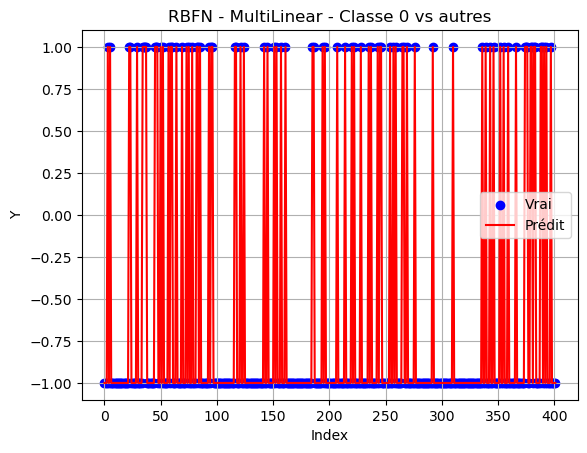

In [13]:
# Même génération de données
X = np.random.random((500, 2)) * 2.0 - 1.0
Y = np.array([
    [1, 0, 0] if -p[0] - p[1] - 0.5 > 0 and p[1] < 0 and p[0] - p[1] - 0.5 < 0 else 
    [0, 1, 0] if -p[0] - p[1] - 0.5 < 0 and p[1] > 0 and p[0] - p[1] - 0.5 < 0 else 
    [0, 0, 1] if -p[0] - p[1] - 0.5 < 0 and p[1] < 0 and p[0] - p[1] - 0.5 > 0 else 
    [0, 0, 0] for p in X
])

# Suppression des points ambigus
X = X[~np.all(Y == [0, 0, 0], axis=1)]
Y = Y[~np.all(Y == [0, 0, 0], axis=1)]
labels = np.argmax(Y, axis=1)  # convert one-hot to class index

# Créer un binaire : classe 0 vs le reste
Y_binary = np.where(labels == 0, 1, -1)

# Appel du test RBFN en mode binaire
test_rbfn_model(lib, X, Y_binary, "RBFN - MultiLinear - Classe 0 vs autres", mode="binary")


#test_rbfn_model(lib, X, labels, "RBFN - MultiLinear - 3 classes", mode="multiclass", n_classes=3)


# Cas classification multiclasses


--- Classification multiclasses ---
Mode : Classification multiclasses (descente de gradient)
Exemple 0 : Prédit = 0.000, Vrai = 0
Exemple 1 : Prédit = 0.000, Vrai = 0
Exemple 2 : Prédit = 0.000, Vrai = 0
Exemple 3 : Prédit = 2.000, Vrai = 2
Exemple 4 : Prédit = 2.000, Vrai = 2
Exemple 5 : Prédit = 2.000, Vrai = 2
Exemple 6 : Prédit = 0.000, Vrai = 0
Exemple 7 : Prédit = 0.000, Vrai = 0
Exemple 8 : Prédit = 2.000, Vrai = 2
Exemple 9 : Prédit = 0.000, Vrai = 0
Exemple 10 : Prédit = 2.000, Vrai = 2
Exemple 11 : Prédit = 2.000, Vrai = 2
Exemple 12 : Prédit = 0.000, Vrai = 0
Exemple 13 : Prédit = 0.000, Vrai = 1
Exemple 14 : Prédit = 2.000, Vrai = 2
Exemple 15 : Prédit = 0.000, Vrai = 1
Exemple 16 : Prédit = 1.000, Vrai = 2
Exemple 17 : Prédit = 2.000, Vrai = 2
Exemple 18 : Prédit = 0.000, Vrai = 1
Exemple 19 : Prédit = 2.000, Vrai = 2
Exemple 20 : Prédit = 1.000, Vrai = 0
Exemple 21 : Prédit = 2.000, Vrai = 2
Exemple 22 : Prédit = 0.000, Vrai = 0
Exemple 23 : Prédit = 0.000, Vrai = 0
Exe

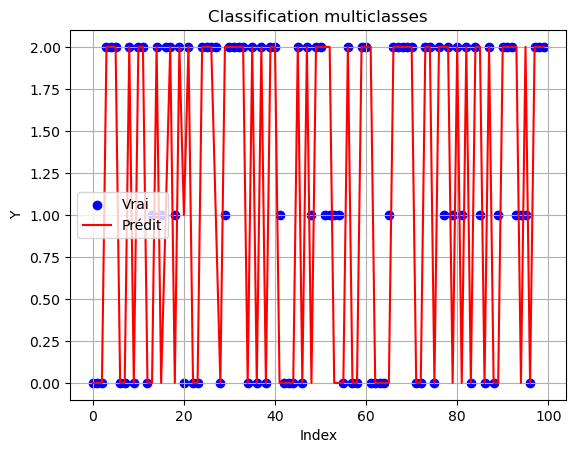

In [14]:
X = np.random.random((100, 2)) * 2 - 1
Y = np.array([
    [1, 0, 0] if x[0] > 0 and x[1] > 0 else
    [0, 1, 0] if x[0] < 0 and x[1] > 0 else
    [0, 0, 1] for x in X
])
Y_class = np.argmax(Y, axis=1)
test_rbfn_model(lib, X, Y_class, "Classification multiclasses", mode="multiclass", n_classes=3)


# cas 5 : MultiLinear 


--- RBFN - MultiLinear - 3 classes ---
Mode : Classification multiclasses (descente de gradient)
Exemple 0 : Prédit = 0.000, Vrai = 1
Exemple 1 : Prédit = 2.000, Vrai = 1
Exemple 2 : Prédit = 0.000, Vrai = 1
Exemple 3 : Prédit = 2.000, Vrai = 2
Exemple 4 : Prédit = 2.000, Vrai = 0
Exemple 5 : Prédit = 2.000, Vrai = 0
Exemple 6 : Prédit = 1.000, Vrai = 1
Exemple 7 : Prédit = 2.000, Vrai = 0
Exemple 8 : Prédit = 2.000, Vrai = 0
Exemple 9 : Prédit = 2.000, Vrai = 2
Exemple 10 : Prédit = 0.000, Vrai = 1
Exemple 11 : Prédit = 2.000, Vrai = 1
Exemple 12 : Prédit = 0.000, Vrai = 1
Exemple 13 : Prédit = 0.000, Vrai = 1
Exemple 14 : Prédit = 0.000, Vrai = 1
Exemple 15 : Prédit = 1.000, Vrai = 0
Exemple 16 : Prédit = 2.000, Vrai = 2
Exemple 17 : Prédit = 2.000, Vrai = 1
Exemple 18 : Prédit = 2.000, Vrai = 0
Exemple 19 : Prédit = 2.000, Vrai = 0
Exemple 20 : Prédit = 0.000, Vrai = 1
Exemple 21 : Prédit = 2.000, Vrai = 0
Exemple 22 : Prédit = 2.000, Vrai = 2
Exemple 23 : Prédit = 2.000, Vrai = 1


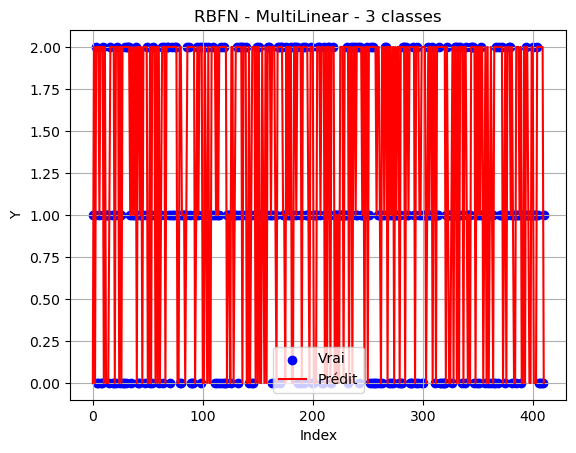

In [16]:
# === Test classificqtion binaire (3 classes) ===
X = np.random.random((500, 2)) * 2.0 - 1.0
Y = np.array([
    [1, 0, 0] if -p[0] - p[1] - 0.5 > 0 and p[1] < 0 and p[0] - p[1] - 0.5 < 0 else 
    [0, 1, 0] if -p[0] - p[1] - 0.5 < 0 and p[1] > 0 and p[0] - p[1] - 0.5 < 0 else 
    [0, 0, 1] if -p[0] - p[1] - 0.5 < 0 and p[1] < 0 and p[0] - p[1] - 0.5 > 0 else 
    [0, 0, 0] for p in X
])

X = X[~np.all(Y == [0, 0, 0], axis=1)]
Y = Y[~np.all(Y == [0, 0, 0], axis=1)]
labels = np.argmax(Y, axis=1)  # convert one-hot to class index: 0, 1, 2


Y_binary = np.where(labels == 0, 1, -1)
#test_rbfn_model(lib, X, Y_binary, "Classification - MultiLinear - Classe 0 vs autres", mode="binary")
test_rbfn_model(lib, X, labels, "RBFN - MultiLinear - 3 classes", mode="multiclass", n_classes=3)